<a href="https://colab.research.google.com/github/Sakhiur2022/Signal/blob/main/notebooks/06_subgroup_analysis/01_subgroup_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPR-06 — Subgroup Analysis

**Ticket:** SPR-06
**Owner:** TBD
**Depends on:** SPR-05 (SHAP values)
**Folder:** `notebooks/06_subgroup_analysis/`
**Output:** written comparison of which subgroup shows the strongest digital-access effect

**No reference notebook covers this.** None of the four uploaded notebooks (SOTA_Paper_8, cross-validation, XAI_Occupational_Stress, RFECV) contain subgroup analysis; their 'Model Interpretation' sections were placeholder headers only. This notebook is built from the project's original deeper research questions: does the effect of digital_index differ across education level, agri/non-agri employment, disability status, gender, and region.

## 0. Hugging Face setup: login and download data/models
Run this once per Colab session. It authenticates against the `Sakhiur/signal` repo and pulls the CSVs used below. Add your token in Colab's left sidebar (key icon) under the name `HF_TOKEN` before running this cell.

In [ ]:
!pip install -q huggingface_hub

import os
from google.colab import userdata
from huggingface_hub import login, hf_hub_download

login(token=userdata.get('HF_TOKEN'))

REPO_ID = 'Sakhiur/signal'

os.makedirs('data/interim', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

hf_files = {
    'X_test_Sakhiur.csv': 'data/interim/X_test.csv',
    'X_train_resampled_Sakhiur.csv': 'data/interim/X_train_resampled.csv',
    'y_test_Sakhiur.csv': 'data/interim/y_test.csv',
    'y_train_resampled_Sakhiur.csv': 'data/interim/y_train_resampled.csv',
}

for repo_filename, local_path in hf_files.items():
    downloaded = hf_hub_download(
        repo_id=REPO_ID,
        repo_type='dataset',
        filename=repo_filename,
    )
    import shutil
    shutil.copy(downloaded, local_path)
    print(f'{repo_filename} -> {local_path}')

print('All data files ready.')

X_test_Sakhiur.csv -> data/interim/X_test.csv
X_train_resampled_Sakhiur.csv -> data/interim/X_train_resampled.csv
y_test_Sakhiur.csv -> data/interim/y_test.csv
y_train_resampled_Sakhiur.csv -> data/interim/y_train_resampled.csv
All data files ready.


In [ ]:
from huggingface_hub import snapshot_download

models_dir = snapshot_download(
    repo_id=REPO_ID,
    repo_type='dataset',
    allow_patterns='results/*',
    local_dir='.',
)
print('Results downloaded to ./results/')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 53 files:   0%|          | 0/53 [00:00<?, ?it/s]

Results downloaded to ./results/


## 1. Load SHAP values and matching features from SPR-05

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

shap_data = np.load('results/shap/shap_values.npz')
X_sample = pd.read_csv('results/shap/shap_sample_features.csv')

class_names = [k.replace('class_', '') for k in shap_data.files]
print('Classes found:', class_names)
print('Sample shape:', X_sample.shape)

Classes found: ['Lower', 'Middle', 'No_income', 'Upper']
Sample shape: (500, 25)


## 2. Define subgroup splits
Matches the deeper research questions from the project plan: highly educated vs less educated, agri vs non-agri, disabled vs non-disabled, gender, region.

In [ ]:
# Education split at the median, adjust threshold if a domain-specific cutoff is preferred
edu_median = X_sample['education_years'].median()
X_sample['edu_group'] = np.where(
    X_sample['education_years'] >= edu_median, 'Higher_education', 'Lower_education'
)

X_sample['agri_group'] = np.where(X_sample['agri_worker'] == 1, 'Agri', 'Non_agri')
X_sample['disability_group'] = np.where(X_sample['disabled'] == 1, 'Disabled', 'Non_disabled')
X_sample['gender_group'] = np.where(X_sample['gender_male'] == 1, 'Male', 'Female')

region_cols = [c for c in X_sample.columns if c.startswith('region_')]
X_sample['region_group'] = X_sample[region_cols].idxmax(axis=1).str.replace('region_', '')

subgroup_cols = ['edu_group', 'agri_group', 'disability_group', 'gender_group', 'region_group']
X_sample[subgroup_cols].describe(include='all')

,edu_group,agri_group,disability_group,gender_group,region_group
count,500,500,500,500,500
unique,2,2,2,2,6
top,Higher_education,Non_agri,Non_disabled,Female,Sumatra
freq,297,493,467,251,141


## 3. Mean |SHAP value| for digital_index, per subgroup
This is the core comparison. A higher mean absolute SHAP value means digital_index matters more for that subgroup's predicted income class.

In [ ]:
# Use the 'Upper' income class SHAP values as the primary lens, since the original MNLogit finding
# was about odds of reaching higher income tiers. Adjust TARGET_CLASS if a different class is of interest.
TARGET_CLASS = class_names[-1]  # TODO: confirm this is 'Upper'
digital_index_col_pos = list(X_sample.drop(columns=subgroup_cols).columns).index('digital_index')
sv = shap_data[f'class_{TARGET_CLASS}']
digital_shap = sv[:, digital_index_col_pos]

X_sample['digital_index_shap'] = digital_shap

for col in subgroup_cols:
    summary = X_sample.groupby(col)['digital_index_shap'].agg(['mean', 'std', 'count'])
    summary['mean_abs'] = X_sample.groupby(col)['digital_index_shap'].apply(lambda s: s.abs().mean())
    print(f'--- {col} ---')
    print(summary.sort_values('mean_abs', ascending=False))
    print()

--- edu_group ---
                      mean       std  count  mean_abs
edu_group                                            
Lower_education  -0.760389  0.456054    203  0.829971
Higher_education -0.525107  0.703149    297  0.793941

--- agri_group ---
                mean       std  count  mean_abs
agri_group                                     
Agri       -0.904838  0.373706      7  0.904838
Non_agri   -0.616596  0.627333    493  0.807203

--- disability_group ---
                      mean       std  count  mean_abs
disability_group                                     
Disabled         -0.720675  0.467737     33  0.823161
Non_disabled     -0.613562  0.634626    467  0.807538

--- gender_group ---
                  mean       std  count  mean_abs
gender_group                                     
Female       -0.680679  0.559592    251  0.840250
Male         -0.560102  0.680764    249  0.776635

--- region_group ---
                  mean       std  count  mean_abs
region_group      

## 4. Visualize subgroup comparison

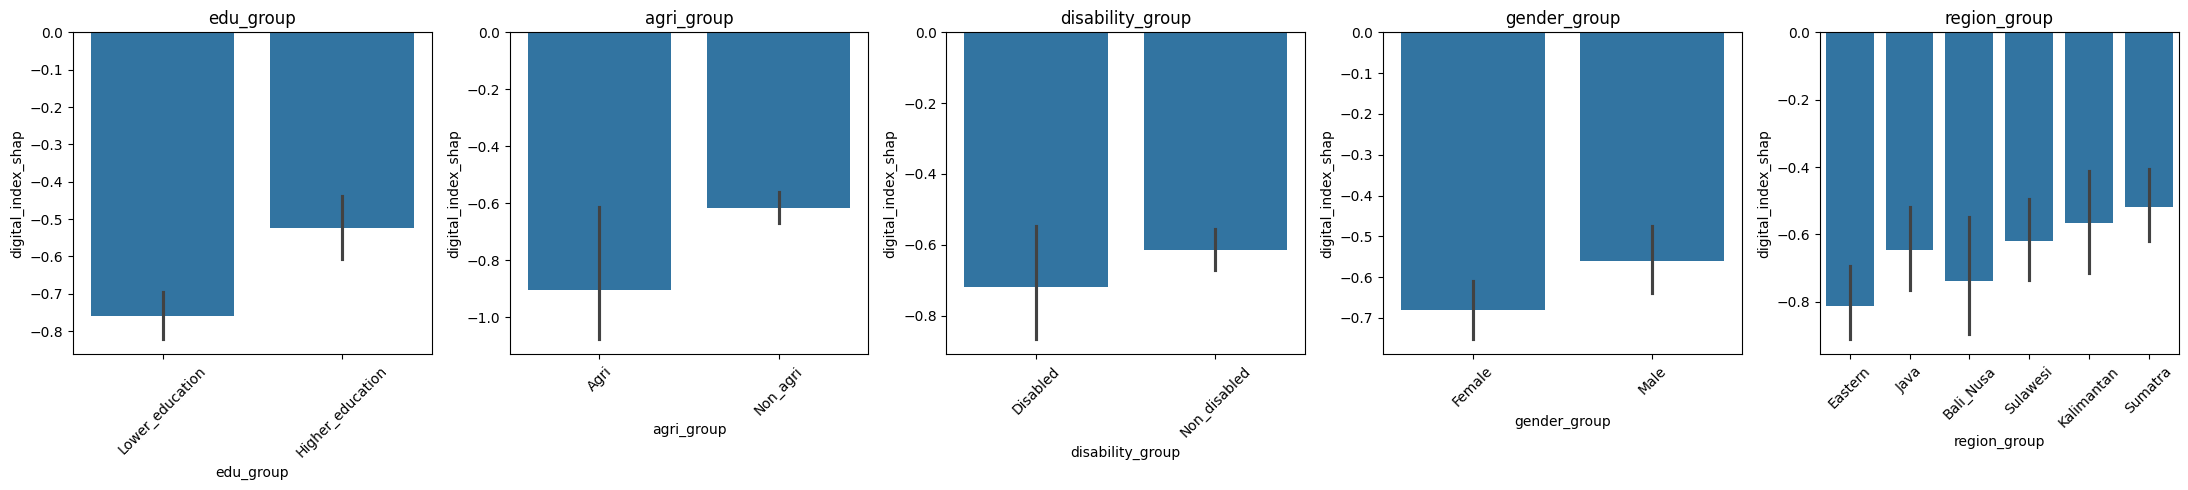

In [ ]:
fig, axes = plt.subplots(1, len(subgroup_cols), figsize=(22, 5))
for ax, col in zip(axes, subgroup_cols):
    order = X_sample.groupby(col)['digital_index_shap'].apply(lambda s: s.abs().mean()).sort_values(ascending=False).index
    sns.barplot(data=X_sample, x=col, y='digital_index_shap', ax=ax, order=order, errorbar='ci')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig('results/figures/subgroup_digital_index_shap.png', dpi=200)
plt.show()

## 5. Statistical check: does the SHAP value distribution actually differ across subgroups?
Mann-Whitney U for two-group splits, Kruskal-Wallis for region (more than two groups). Non-parametric since SHAP value distributions are not guaranteed to be normal.

In [ ]:
from scipy.stats import mannwhitneyu, kruskal

two_group_cols = ['edu_group', 'agri_group', 'disability_group', 'gender_group']
for col in two_group_cols:
    groups = X_sample.groupby(col)['digital_index_shap'].apply(list)
    if len(groups) == 2:
        stat, p = mannwhitneyu(groups.iloc[0], groups.iloc[1])
        print(f'{col}: Mann-Whitney U p-value = {p:.4f}', '(significant)' if p < 0.05 else '(not significant)')

region_groups = X_sample.groupby('region_group')['digital_index_shap'].apply(list)
stat, p = kruskal(*region_groups)
print(f'region_group: Kruskal-Wallis p-value = {p:.4f}', '(significant)' if p < 0.05 else '(not significant)')

edu_group: Mann-Whitney U p-value = 0.0237 (significant)
agri_group: Mann-Whitney U p-value = 0.0610 (not significant)
disability_group: Mann-Whitney U p-value = 0.5128 (not significant)
gender_group: Mann-Whitney U p-value = 0.1915 (not significant)
region_group: Kruskal-Wallis p-value = 0.0009 (significant)


## 6. Save subgroup results table

In [ ]:
import os
os.makedirs('results/tables', exist_ok=True)

all_summaries = []
for col in subgroup_cols:
    s = X_sample.groupby(col)['digital_index_shap'].agg(['mean', 'std', 'count'])
    s['mean_abs'] = X_sample.groupby(col)['digital_index_shap'].apply(lambda x: x.abs().mean())
    s['subgroup_dimension'] = col
    s = s.reset_index().rename(columns={col: 'group'})
    all_summaries.append(s)

subgroup_table = pd.concat(all_summaries, ignore_index=True)
subgroup_table.to_csv('results/tables/subgroup_analysis.csv', index=False)
subgroup_table

,group,mean,std,count,mean_abs,subgroup_dimension
0,Higher_education,-0.525107,0.703149,297,0.793941,edu_group
1,Lower_education,-0.760389,0.456054,203,0.829971,edu_group
2,Agri,-0.904838,0.373706,7,0.904838,agri_group
3,Non_agri,-0.616596,0.627333,493,0.807203,agri_group
4,Disabled,-0.720675,0.467737,33,0.823161,disability_group
5,Non_disabled,-0.613562,0.634626,467,0.807538,disability_group
6,Female,-0.680679,0.559592,251,0.840250,gender_group
7,Male,-0.560102,0.680764,249,0.776635,gender_group
8,Bali_Nusa,-0.739480,0.507689,34,0.860770,region_group
9,Eastern,-0.812933,0.418920,55,0.884917,region_group


## 7. Written comparison
_Fill in after reviewing the outputs above. This is the deliverable SPR-07 depends on._

- Subgroup with the strongest digital_index effect:
- Subgroup with the weakest effect:
- Which splits were statistically significant:
- Candidate interactions to test formally in SPR-07: